# 音频零基础 1/6：振动、波形与时间轴

这节课从生活中的声音出发，再落到 Python 数组。**先建立直觉，再看公式，最后用代码验证。**

| 项目 | 内容 |
|---|---|
| 本课要回答的问题 | 声音是什么，为什么能画成一条随时间变化的曲线？ |
| 前置要求 | 会运行 Notebook；看不懂代码时先读 Python/PyTorch 基础 1～3 |
| 建议投入 | 90～120 分钟，分成“直觉”和“代码”两次完成也可以 |
| 四个关键词 | 振动、时间轴、波形、采样值 |
| 通关证据 | 能用自己的话解释、能算一个数字例子、能画图验证、能从空白实现核心函数 |

本课不是词汇表。每出现一个量，都要写清楚：**它描述什么、单位是什么、数组中怎样表示、改变后听觉或图形怎样变化。**


## 课前回忆：先写猜测，不查答案

1. 对问题“声音是什么，为什么能画成一条随时间变化的曲线？”写下你现在的答案；不会就写“不知道”。
2. 四个关键词中，圈出最陌生的一个：振动 / 时间轴 / 波形 / 采样值。
3. 画一条横轴是时间的线，标出 0 秒、0.5 秒和 1 秒。
4. 写下一个可验证的预测：如果把声音的某个参数加倍，图或听感会怎样？

学完后回到这里，用另一种颜色修正。保留错误猜测，它是学习证据。


## 固定观察框架：物理世界 → 数字 → 图 → 听感

```text
声源振动 → 空气压力随时间变化 → 麦克风电信号 → 离散采样值 x[n]
                                                ↓
                                      波形 / 数值统计 / 频谱
```

后面所有 ASR 前端课都沿这条链展开。波形不是声音本身，而是麦克风在一串离散时刻记录下来的数字。


## 1. 从慢振动开始：先看得见，再谈听得见

物体来回运动叫振动。麦克风记录的是这种变化引起的空气压力变化。下面先画 2 Hz 的慢振动。


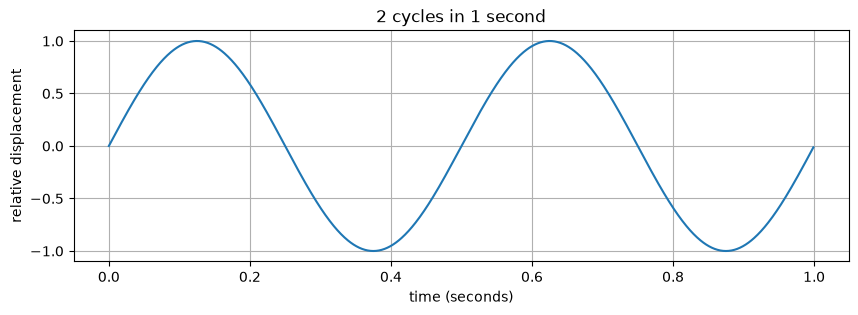

In [1]:
import numpy as np
import matplotlib.pyplot as plt

duration_seconds = 1.0
points_for_drawing = 1000
time_seconds = np.linspace(0, duration_seconds, points_for_drawing, endpoint=False)
slow_vibration = np.sin(2 * np.pi * 2 * time_seconds)

plt.figure(figsize=(10, 3))
plt.plot(time_seconds, slow_vibration)
plt.xlabel("time (seconds)")
plt.ylabel("relative displacement")
plt.title("2 cycles in 1 second")
plt.grid(True)
plt.show()

assert time_seconds.shape == slow_vibration.shape == (1000,)


## 2. 横轴与纵轴分别回答什么

横轴回答“什么时候”，纵轴回答“相对平衡位置偏了多少”。正负号表示方向，不代表好坏。


In [2]:
for index in [0, 125, 250, 375, 500]:
    print(f"index={index:3d}, time={time_seconds[index]:.3f} s, value={slow_vibration[index]:+.3f}")

print("shape:", slow_vibration.shape)
print("dtype:", slow_vibration.dtype)
print("min/max:", slow_vibration.min(), slow_vibration.max())


index=  0, time=0.000 s, value=+0.000
index=125, time=0.125 s, value=+1.000
index=250, time=0.250 s, value=+0.000
index=375, time=0.375 s, value=-1.000
index=500, time=0.500 s, value=-0.000
shape: (1000,)
dtype: float64
min/max: -1.0 1.0


## 3. 毫秒只是更方便的时间单位

1 秒 = 1000 毫秒。ASR 常用 25 ms 帧长、10 ms 帧移，但它们仍然只是时间。


In [3]:
def milliseconds_to_seconds(milliseconds: float) -> float:
    if milliseconds < 0:
        raise ValueError("milliseconds must be non-negative")
    return milliseconds / 1000.0


for ms in [1, 10, 25, 100, 1000]:
    print(f"{ms:4d} ms = {milliseconds_to_seconds(ms):.3f} s")

assert milliseconds_to_seconds(25) == 0.025


   1 ms = 0.001 s
  10 ms = 0.010 s
  25 ms = 0.025 s
 100 ms = 0.100 s
1000 ms = 1.000 s


## 4. 数组只是按时间顺序保存的测量值

`x[n]` 中的 `n` 是样本序号。只看 `n` 不知道真实时间；还必须知道采样率，这会在第 4 节桥梁课完整学习。


In [4]:
first_ten = slow_vibration[:10]
print(first_ten)
print("第 4 个值 x[3] =", first_ten[3])
assert len(first_ten) == 10


[0.         0.01256604 0.0251301  0.03769018 0.05024432 0.06279052
 0.07532681 0.0878512  0.10036171 0.11285638]
第 4 个值 x[3] = 0.03769018266993454


## 分层练习：不要一次做完

### A. 直觉与单位（每题 1 分）

1. 不看上文，用一句话定义：振动。
2. 为 `时间轴` 写出单位；如果它没有单位，要明确说明。
3. 举一个生活中的例子解释 `波形`。
4. 画图说明 `采样值` 增大时，横轴或纵轴怎样变化。

### B. 数字与预测（每题 2 分）

5. 自己构造一个包含具体数字的计算例子，并标出每一步单位。
6. 把本课一个参数改成 0.5 倍和 2 倍；运行前先画出预期图形。
7. 找出一个“代码能运行，但物理含义错误”的输入，解释为什么错误。
8. 用 `shape / dtype / min / max` 四项审计本课最重要的数组。

### C. 实现与迁移（每题 3 分）

9. 从空白实现：**实现 milliseconds_to_seconds，并写出负数输入策略**，不能复制上面的函数。
10. 为实现写正常、边界和错误输入三类测试。
11. 换一组参数或换一条音频，验证结论是否仍成立。
12. 用 90 秒向没学过编程的人解释本课，只允许使用两个术语，并必须包含一个数字例子。

满分 24 分。达到 19 分且第 9～10 题完成，才建议继续；15～18 分次日重做；低于 15 分先回到图和单位。


## 最小掌握门禁

- [ ] 我能把本课每个量说成“含义 + 单位 + 数组表示”。
- [ ] 我能在运行前预测参数变化的方向。
- [ ] 我能从空白完成核心实现并覆盖边界输入。
- [ ] 我能说出一个常见误解，以及用什么证据推翻它。
- [ ] 我已把错题写入根目录 `LEARNING_LOG.md`，并安排明天、7 天、30 天复习。

下一步：音频基础 2：周期、频率、相位与正弦波。
